# 알고리즘 거래전략 기말과제

20249132 김형환

In [1]:
from tqdm import tqdm
from statsmodels.tsa.stattools import adfuller
from itertools import combinations, product
from joblib import Parallel, delayed
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 기존 데이터를 R로 가공하여 2022~2024의 snp500구성종목 데이터만 남기고, long form으로 변환
snp500_return = pd.read_csv("data/snp500_return.csv")
snp500_return['date'] = pd.to_datetime(snp500_return['date'])
snp500_return.head()

,date,permno,ticker,comnam,return
0,2022-01-03,10104,ORCL,ORACLE CORP,0.007912
1,2022-01-03,10107,MSFT,MICROSOFT CORP,-0.004668
2,2022-01-03,10138,TROW,T ROWE PRICE GROUP INC,-0.010476
3,2022-01-03,10145,HON,HONEYWELL INTERNATIONAL INC,-0.008201
4,2022-01-03,10516,ADM,ARCHER DANIELS MIDLAND CO,0.004439


In [3]:
# 공적분 관계 검정을 위해 wide form 생성, 추후 전략 성능평가를 위해 24년 1년간은 테스트 목적으로 분할
snp500_return_train = snp500_return[snp500_return["date"] < "2024-01-01"]
snp500_return_test  = snp500_return[snp500_return["date"] >= "2024-01-01"]

snp500_return_wide = snp500_return_train.pivot(index='date', columns='permno', values='return').dropna(axis=1)
snp500_return_wide_test = snp500_return_test.pivot(index='date', columns='permno', values='return').dropna(axis=1)

snp500_prices_wide = (1 + snp500_return_wide).cumprod()
snp500_prices_wide_test = (1 + snp500_return_wide_test).cumprod()

print(snp500_return_wide.info())
print(snp500_return_wide_test.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2022-01-03 to 2023-12-29
Columns: 456 entries, 10104 to 93436
dtypes: float64(456)
memory usage: 1.7 MB
None
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2024-01-02 to 2024-12-31
Columns: 456 entries, 10104 to 93436
dtypes: float64(456)
memory usage: 899.7 KB
None


In [4]:
# 공적분 검정 이전 계산량 효율화를 위한 사전 스크리닝
# 1. 단일 ADF검정 활용
alpha = 0.05

tqdm.pandas(desc="ADF Test")
pvals = snp500_prices_wide.progress_apply(lambda ts: adfuller(ts)[1])
non_sta = pvals[pvals >= alpha].index.tolist()
filtered_prices_wide = snp500_prices_wide[non_sta]

print(f"Number of total stocks : {len(pvals)}")
print(f"Number of non-stationary stocks(p<{alpha}) : {len(non_sta)}")

ADF Test: 100%|██████████| 456/456 [00:03<00:00, 130.26it/s]

Number of total stocks : 456
Number of non-stationary stocks(p<0.05) : 370


In [5]:
# 공적분 검정 이전 계산량 효율화를 위한 사전 스크리닝
# 2. 상관계수 활용
corr_threshold = 0.3

corr = filtered_prices_wide.corr().abs()
pairs = [
    (i, j)
    for i, j in combinations(filtered_prices_wide.columns, 2)
    if corr.loc[i, j] > corr_threshold]

print(f"Number of whole pairs : {len(list(combinations(filtered_prices_wide.columns, 2)))}")
print(f"Number of correlated(>{corr_threshold}) pairs : {len(pairs)}")

Number of whole pairs : 68265
Number of correlated(>0.3) pairs : 43997


In [6]:
# Engle-Granger 테스트를 통해 공적분 관계 검정정

alpha_coint = 0.01
min_obs = 50

def test_pair(pair):
    t1, t2 = pair
    df = filtered_prices_wide[[t1, t2]].dropna()
    if len(df) < min_obs:
        return None
    y = df[t1]
    x = sm.add_constant(df[t2])
    model = sm.OLS(y, x).fit()
    resid = model.resid
    try:
        pval = adfuller(resid, autolag=None)[1]
        if pval < alpha_coint:
            return {"permno_1": t1, "permno_2": t2, "pvalue": pval}
    except:
        return None
    return None

results = Parallel(n_jobs=-1, verbose=5)(
    delayed(test_pair)(pair) for pair in pairs
)

results = [r for r in results if r is not None]
coint_pairs = pd.DataFrame(results)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 2080 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 7264 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 13600 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done 21088 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-1)]: Done 29728 tasks      | elapsed:   22.1s
[Parallel(n_jobs=-1)]: Done 39520 tasks      | elapsed:   27.4s
[Parallel(n_jobs=-1)]: Done 43966 out of 43997 | elapsed:   30.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 43997 out of 43997 | elapsed:   30.5s finished


In [7]:
print(f"Number of cointegrated(significant level={alpha_coint:.0%}) pairs : {len(coint_pairs)}")

Number of cointegrated(significant level=1%) pairs : 2565


In [8]:
# 상위 5개 공적분 페어 추출
comnam_map = snp500_return.drop_duplicates("permno").set_index("permno")["comnam"].to_dict()
top5_pairs = coint_pairs.sort_values("pvalue").head(5).copy()
top5_pairs["comnam_1"], top5_pairs["comnam_2"] = top5_pairs["permno_1"].map(comnam_map), top5_pairs["permno_2"].map(comnam_map)

top5_pairs

,permno_1,permno_2,pvalue,comnam_1,comnam_2
320,11850,93246,9.981788e-07,EXXON MOBIL CORP,GENERAC HOLDINGS INC
2308,76605,77730,1.170548e-05,AUTOZONE INC,TYSON FOODS INC
376,13407,86580,1.595093e-05,META PLATFORMS INC,NVIDIA CORP
1419,24643,52708,1.624042e-05,HOWMET AEROSPACE INC,LENNAR CORP
2495,87137,90215,2.325270e-05,DEVON ENERGY CORP NEW,SALESFORCE INC


In [9]:
# Pair들에 대한 반감기, Historical Mean Crossing, 헤지비율, Hurst 지수, Pearson Corr 계산
pair_list   = list(coint_pairs[["permno_1","permno_2","pvalue"]].itertuples(index=False))
total_pairs = len(pair_list)

records = []
for permno_1, permno_2, pval in tqdm(pair_list, total=total_pairs, desc="Compute metrics"):
    
    pair = pd.concat([filtered_prices_wide[permno_1], filtered_prices_wide[permno_2]], axis=1, join='inner').dropna()
    if len(pair) < 252:
        continue2
    y1, y2 = pair.iloc[:,0], pair.iloc[:,1]

    # OLS로 hedge ratio β 추정
    X   = sm.add_constant(y2.values)
    res = sm.OLS(y1.values, X).fit()
    beta = res.params[1]

    spread = y1 - beta * y2

    # Hurst exponent
    lags = np.array([2,5,10,20,50])
    tau  = np.array([np.std(spread.diff(l).dropna()) for l in lags])
    H    = np.polyfit(np.log(lags), np.log(tau), 1)[0]

    # Half-life
    spread_lag    = spread.shift(1).dropna()
    spread_ret    = spread.diff().dropna().loc[spread_lag.index]
    reg           = sm.OLS(spread_ret.values, sm.add_constant(spread_lag.values)).fit()
    b_coef        = reg.params[1]
    phi_ar        = b_coef + 1
    half_life     = -np.log(2) / np.log(phi_ar)

    # Historical mean crossings per year
    m               = spread.mean()
    centered        = spread - m
    signs           = np.sign(centered)
    crossings       = np.sum(signs.diff().fillna(0) != 0)
    years           = (spread.index[-1] - spread.index[0]).days / 365.25
    mean_cross_year = crossings / years

    # Pearson Corr
    ret_pair = snp500_return_wide.loc[:, [permno_1, permno_2]].dropna(how="any")
    pearson_corr = ret_pair.corr().iloc[0,1] if len(ret_pair) > 1 else np.nan

    records.append({
        "permno_1":        permno_1,
        "permno_2":        permno_2,
        "pvalue":          pval,
        "hedge_ratio":     beta,
        "hurst":           H,
        "half_life":       half_life,
        "mean_cross_year": mean_cross_year,
        "pearson_corr":    pearson_corr
    })

metrics_df_1pct = pd.DataFrame(records)
metrics_df_1pct["comnam_1"] = metrics_df_1pct["permno_1"].map(comnam_map)
metrics_df_1pct["comnam_2"] = metrics_df_1pct["permno_2"].map(comnam_map)

Compute metrics: 100%|██████████| 2565/2565 [00:23<00:00, 111.44it/s]


In [10]:
# Hurst,Half-life,Mean-crossings,pearson_corr 필터링
filtered_pairs = metrics_df_1pct[
    (metrics_df_1pct["hurst"]           < 0.5)   &
    (metrics_df_1pct["half_life"]       > 1)     &
    (metrics_df_1pct["half_life"]       < 30)    &
    (metrics_df_1pct["mean_cross_year"] > 5)    &
    (metrics_df_1pct["pearson_corr"] > 0.5)
].copy()

# 점수 계산 및 최우수 페어 추출
filtered_pairs["score"] = (
    -filtered_pairs["pvalue"].rank() +
    -filtered_pairs["half_life"].rank() +
    filtered_pairs["mean_cross_year"].rank() +
    filtered_pairs["pearson_corr"].rank()
)

best5_pairs = filtered_pairs.sort_values("score", ascending=False).iloc[0:5]

print(f"Number of Filtered pairs : {len(filtered_pairs)}")
best5_pairs

Number of Filtered pairs : 322


,permno_1,permno_2,pvalue,hedge_ratio,hurst,half_life,mean_cross_year,pearson_corr,comnam_1,comnam_2,score
853,19286,78987,0.000158,0.680322,0.314507,7.191855,32.242759,0.605119,OTIS WORLDWIDE CORP,MICROCHIP TECHNOLOGY INC,557.5
340,12084,48486,0.001111,0.596882,0.360651,10.127506,29.220000,0.792955,N X P SEMICONDUCTORS N V,LAM RESH CORP,543.5
2107,58819,64936,0.000495,0.300429,0.402952,12.482854,29.220000,0.761218,ALLIANT ENERGY CORP,DOMINION ENERGY INC,519.5
1178,23931,24109,0.000785,0.848911,0.393015,12.980947,29.220000,0.886921,X C E L ENERGY INC,AMERICAN ELECTRIC POWER CO INC,509.5
848,19286,60871,0.001356,0.737086,0.314549,8.868845,29.723793,0.621187,OTIS WORLDWIDE CORP,ANALOG DEVICES INC,509.0


In [11]:
# 최적 쌍을 이용하여 전략 구성. 성과가 가장 좋은 진입청산기준을 선정해서 test데이터로 평가 실시
pair = best5_pairs.iloc[0]
p1, p2 = pair.permno_1, pair.permno_2
hedge_ratio = pair.hedge_ratio
comnam1, comnam2 = pair.comnam_1, pair.comnam_2

# 가격 데이터
price_is = snp500_prices_wide[[p1, p2]].dropna()
price_is.columns = [comnam1, comnam2]

# 파라미터 후보
entry_z_list = [0.5 ,1.0, 1.5, 2.0, 3.0]
exit_z_list = [0.0, 0.1, 0.3, 0.5]
transaction_cost = 0.0003  # 거래비용 3bp

results = []

for entry_z, exit_z in product(entry_z_list, exit_z_list):
    spread = price_is[comnam1] - hedge_ratio * price_is[comnam2]
    mu, sigma = spread.mean(), spread.std()
    z = (spread - mu) / sigma

    long_entry  = z < -entry_z
    short_entry = z >  entry_z
    exit_signal = z.abs() < exit_z

    # 포지션 설정
    pos = np.where(long_entry, 1,
          np.where(short_entry, -1,
          np.where(exit_signal, 0, np.nan)))
    pos = pd.Series(pos, index=z.index).ffill().fillna(0)

    # 수익률 계산
    ret = price_is.pct_change().dropna()
    strat_ret = pos.shift() * (ret[comnam1] - hedge_ratio * ret[comnam2])

    # 거래비용 반영 (포지션 변경 시 비용 발생)
    pos_chg = pos.diff().abs()
    cost = pos_chg.shift().fillna(0) * transaction_cost
    strat_ret_net = strat_ret - cost

    cum_ret = (1 + strat_ret_net).cumprod()
    sharpe = strat_ret_net.mean() / strat_ret_net.std() * np.sqrt(252)
    mdd = (cum_ret / cum_ret.cummax() - 1).min()

    results.append({
        "entry_z": entry_z,
        "exit_z": exit_z,
        "final_return": cum_ret.iloc[-1],
        "sharpe": sharpe,
        "mdd": mdd
    })

# 결과 정리
opt_results = pd.DataFrame(results).sort_values(by="sharpe", ascending=False).reset_index(drop=True)
display(opt_results)

,entry_z,exit_z,final_return,sharpe,mdd
0,1.5,0.5,2.015736,3.152895,-0.044008
1,1.5,0.3,2.098776,3.035545,-0.056847
2,0.5,0.5,2.709583,2.929092,-0.088697
3,1.0,0.3,2.527457,2.925949,-0.070058
4,1.5,0.1,2.165035,2.904456,-0.068544
5,1.0,0.5,2.366084,2.890452,-0.070058
6,0.5,0.3,2.716753,2.780591,-0.088697
7,0.5,0.1,2.743286,2.626813,-0.088697
8,1.0,0.0,2.926148,2.523193,-0.093610
9,1.0,0.1,2.314327,2.489392,-0.076772


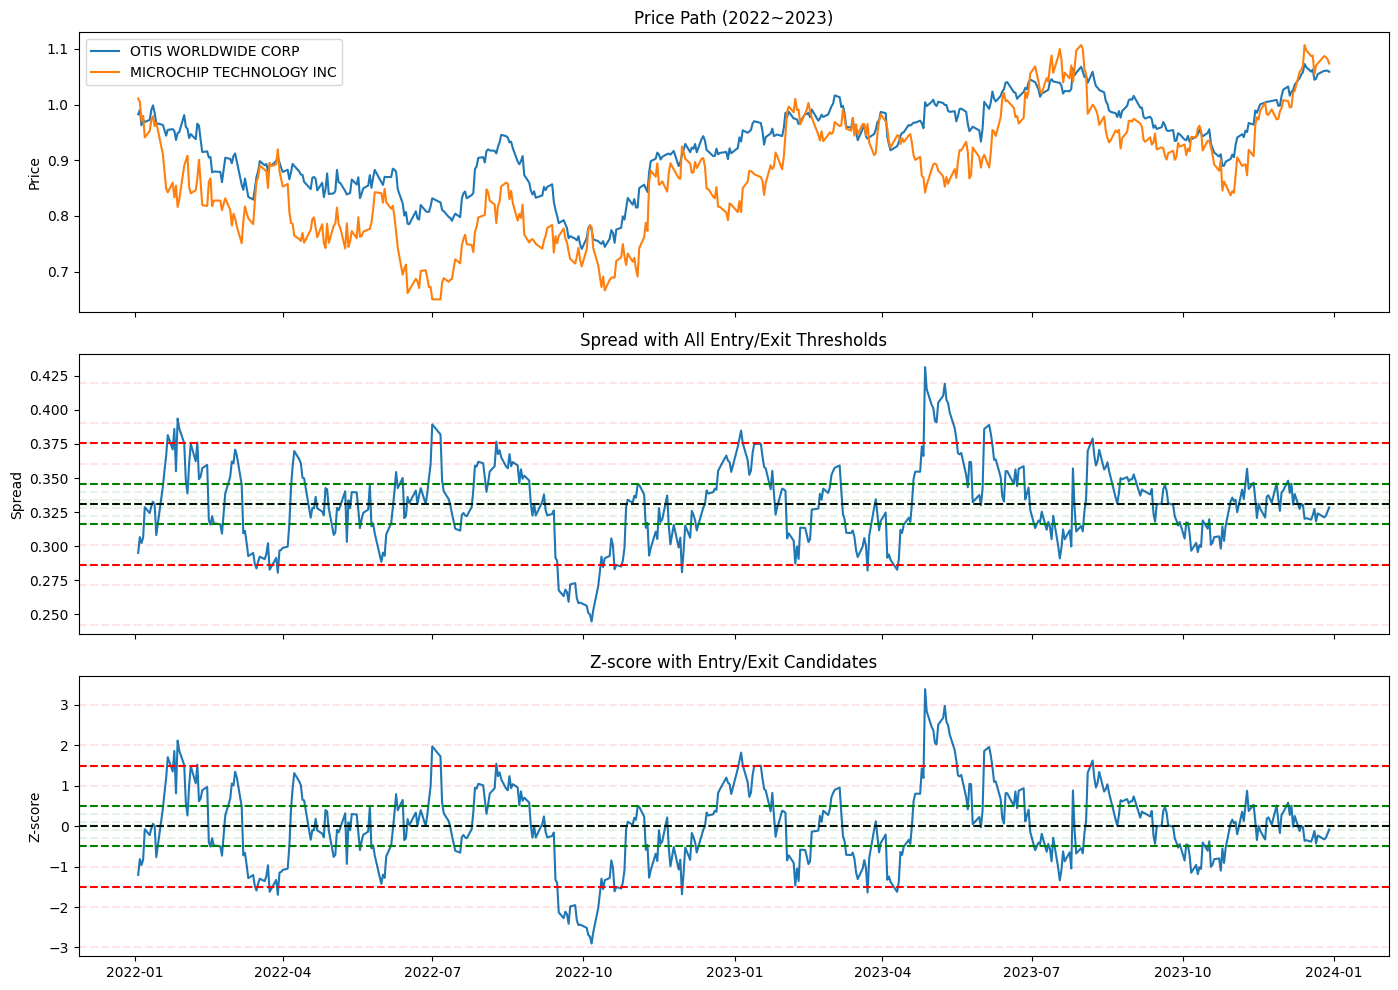

In [12]:
# 최적 entry_z, exit_z
entry_z_opt = opt_results.iloc[0]["entry_z"]
exit_z_opt  = opt_results.iloc[0]["exit_z"]

entry_z_list = [0.5 ,1.0, 1.5, 2.0, 3.0]
exit_z_list = [0.0, 0.1, 0.3, 0.5]

spread = price_is[comnam1] - hedge_ratio * price_is[comnam2]
mu, sigma = spread.mean(), spread.std()
z = (spread - mu) / sigma

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# (1) 가격 경로
axs[0].plot(price_is[comnam1], label=comnam1)
axs[0].plot(price_is[comnam2], label=comnam2)
axs[0].set_ylabel("Price")
axs[0].legend()
axs[0].set_title("Price Path (2022~2023)")

# (2) 스프레드 + 기준선
axs[1].plot(spread, label="Spread")
axs[1].axhline(mu, color="black", linestyle="--", label="Mean")

for ez in entry_z_list:
    alpha = 1.0 if ez == entry_z_opt else 0.1
    axs[1].axhline(mu + sigma * ez, color="red", linestyle="--", alpha=alpha, label=f"+{ez}" if alpha==1.0 else None)
    axs[1].axhline(mu - sigma * ez, color="red", linestyle="--", alpha=alpha, label=f"-{ez}" if alpha==1.0 else None)

for ez in exit_z_list:
    alpha = 1.0 if ez == exit_z_opt else 0.1
    axs[1].axhline(mu + sigma * ez, color="green", linestyle="--", alpha=alpha, label=f"+{ez}" if alpha==1.0 else None)
    axs[1].axhline(mu - sigma * ez, color="green", linestyle="--", alpha=alpha, label=f"-{ez}" if alpha==1.0 else None)

axs[1].set_ylabel("Spread")
axs[1].set_title("Spread with All Entry/Exit Thresholds")

# (3) z-score + 기준선
axs[2].plot(z, label="Z-score")
axs[2].axhline(0, color="black", linestyle="--")

for ez in entry_z_list:
    alpha = 1.0 if ez == entry_z_opt else 0.1
    axs[2].axhline(ez, color="red", linestyle="--", alpha=alpha)
    axs[2].axhline(-ez, color="red", linestyle="--", alpha=alpha)

for ez in exit_z_list:
    alpha = 1.0 if ez == exit_z_opt else 0.1
    axs[2].axhline(ez, color="green", linestyle="--", alpha=alpha)
    axs[2].axhline(-ez, color="green", linestyle="--", alpha=alpha)

axs[2].set_ylabel("Z-score")
axs[2].set_title("Z-score with Entry/Exit Candidates")

plt.tight_layout()
plt.show()

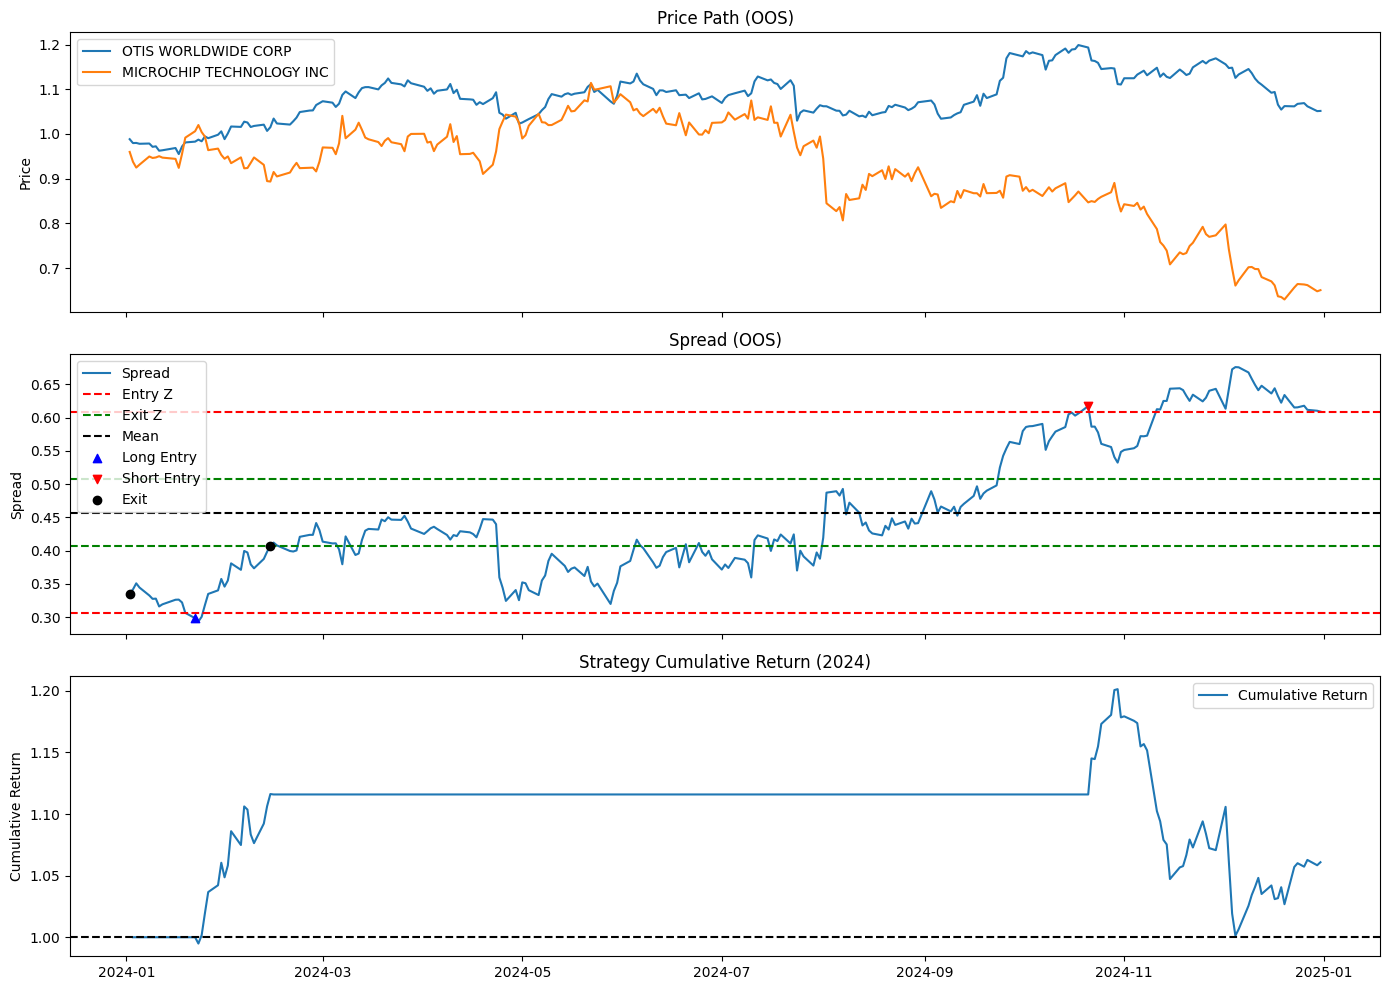

In [13]:
# OOS 가격 데이터
price_oos = snp500_prices_wide_test[[p1, p2]].dropna()
price_oos.columns = [comnam1, comnam2]

# 최적 파라미터
entry_z = opt_results.iloc[0]["entry_z"]
exit_z  = opt_results.iloc[0]["exit_z"]

# 스프레드 및 z-score
spread_oos = price_oos[comnam1] - hedge_ratio * price_oos[comnam2]
mu, sigma = spread_oos.mean(), spread_oos.std()
z_oos = (spread_oos - mu) / sigma

# 포지션
long_entry  = z_oos < -entry_z
short_entry = z_oos >  entry_z
exit_signal = z_oos.abs() < exit_z

pos = np.where(long_entry, 1,
      np.where(short_entry, -1,
      np.where(exit_signal, 0, np.nan)))
pos = pd.Series(pos, index=z_oos.index).ffill().fillna(0)

# 수익률 계산
ret = price_oos.pct_change().dropna()
strat_ret = pos.shift() * (ret[comnam1] - hedge_ratio * ret[comnam2])

# 거래비용 차감
pos_chg = pos.diff().abs().fillna(0)
cost = pos_chg.shift().fillna(0) * transaction_cost
strat_ret_net = strat_ret - cost

cum_ret = (1 + strat_ret_net).cumprod()

# 성과지표
sharpe = strat_ret_net.mean() / strat_ret_net.std() * np.sqrt(252)
mdd = (cum_ret / cum_ret.cummax() - 1).min()

# 진입/청산 시점
entry_longs  = ((pos.shift(1) == 0) & (pos == 1))
entry_shorts = ((pos.shift(1) == 0) & (pos == -1))
exits        = ((pos.shift(1) != 0) & (pos == 0))

entry_longs_idx = entry_longs[entry_longs].index
entry_shorts_idx = entry_shorts[entry_shorts].index
exits_idx = exits[exits].index

# 시각화
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# (1) 가격
axs[0].plot(price_oos[comnam1], label=comnam1)
axs[0].plot(price_oos[comnam2], label=comnam2)
axs[0].set_ylabel("Price")
axs[0].legend()
axs[0].set_title("Price Path (OOS)")

# (2) Spread + Entry/Exit 기준선
axs[1].plot(spread_oos, label="Spread")
axs[1].axhline(mu + sigma * entry_z, color="red", linestyle="--", label="Entry Z")
axs[1].axhline(mu - sigma * entry_z, color="red", linestyle="--")
axs[1].axhline(mu + sigma * exit_z, color="green", linestyle="--", label="Exit Z")
axs[1].axhline(mu - sigma * exit_z, color="green", linestyle="--")
axs[1].axhline(mu, color="black", linestyle="--", label="Mean")

# 진입/청산 화살표
axs[1].scatter(entry_longs_idx, spread_oos.loc[entry_longs_idx], marker='^', color='blue', label='Long Entry', zorder=5)
axs[1].scatter(entry_shorts_idx, spread_oos.loc[entry_shorts_idx], marker='v', color='red', label='Short Entry', zorder=5)
axs[1].scatter(exits_idx, spread_oos.loc[exits_idx], marker='o', color='black', label='Exit', zorder=5)

axs[1].set_ylabel("Spread")
axs[1].legend()
axs[1].set_title("Spread (OOS)")

# (3) 누적 수익률
axs[2].plot(cum_ret, label="Cumulative Return")
axs[2].axhline(1, color="black", linestyle="--")
axs[2].set_ylabel("Cumulative Return")
axs[2].legend()
axs[2].set_title("Strategy Cumulative Return (2024)")

plt.tight_layout()
plt.show()

In [14]:
print("--- Pair tradind Perfomance in 2024 ---")
print(f" 1. Cummulative return : {cum_ret.iloc[-1]:.4f}")
print(f" 2. Sharpe ratio       : {sharpe:.2f}")
print(f" 3. Max Drawdown       : {mdd:.2%}")

--- Pair tradind Perfomance in 2024 ---
 1. Cummulative return : 1.0609
 2. Sharpe ratio       : 0.53
 3. Max Drawdown       : -16.66%
